In [174]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [175]:
df = pd.read_csv(r"C:\Users\kanik\Downloads\Lifestyle_and_Health_Risk_Prediction_Synthetic_Dataset-selected-columns.csv")

In [176]:
df.head()

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession
0,56,67,195,low,6.1,medium,yes,yes,yes,office_worker
1,69,76,170,high,6.9,high,no,no,no,teacher
2,46,106,153,high,6.6,low,yes,no,no,artist
3,32,54,186,medium,8.5,medium,no,no,no,artist
4,60,98,195,high,8.0,low,no,no,yes,teacher


In [177]:
df['BMI'] = df['weight'] / ((df['height'] / 100) ** 2)

In [178]:
df.head()

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,BMI
0,56,67,195,low,6.1,medium,yes,yes,yes,office_worker,17.619987
1,69,76,170,high,6.9,high,no,no,no,teacher,26.297578
2,46,106,153,high,6.6,low,yes,no,no,artist,45.281729
3,32,54,186,medium,8.5,medium,no,no,no,artist,15.608741
4,60,98,195,high,8.0,low,no,no,yes,teacher,25.772518


In [179]:
def calculate_risk_score(row):
    score = 0
    
    if row['age'] > 60:
        score += 2
    elif row['age'] >= 45:
        score += 1
        
    if row['BMI'] > 30:
        score += 2
    elif row['BMI'] >= 25:
        score += 1
        
    if row['smoking'] == 'yes':
        score += 1
        
    if row['alcohol'] == 'yes':
        score += 1
        
    if row['exercise'] == 'none':
        score += 2
    elif row['exercise'] == 'low':
        score += 1
        
    if row['sleep'] < 6:
        score += 1
        
    if row['sugar_intake'] == 'high':
        score += 1
        
    return score

In [180]:
df['risk_score'] = df.apply(calculate_risk_score, axis=1)

In [181]:
df.head()

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,BMI,risk_score
0,56,67,195,low,6.1,medium,yes,yes,yes,office_worker,17.619987,4
1,69,76,170,high,6.9,high,no,no,no,teacher,26.297578,4
2,46,106,153,high,6.6,low,yes,no,no,artist,45.281729,4
3,32,54,186,medium,8.5,medium,no,no,no,artist,15.608741,0
4,60,98,195,high,8.0,low,no,no,yes,teacher,25.772518,2


In [182]:
def get_risk_level(score):
    if score <= 2:
        return 'Low'
    elif score <= 5:
        return 'Medium'
    else:
        return 'High'

In [183]:
df['risk_level'] = df['risk_score'].apply(get_risk_level)

In [184]:
df.head()

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,BMI,risk_score,risk_level
0,56,67,195,low,6.1,medium,yes,yes,yes,office_worker,17.619987,4,Medium
1,69,76,170,high,6.9,high,no,no,no,teacher,26.297578,4,Medium
2,46,106,153,high,6.6,low,yes,no,no,artist,45.281729,4,Medium
3,32,54,186,medium,8.5,medium,no,no,no,artist,15.608741,0,Low
4,60,98,195,high,8.0,low,no,no,yes,teacher,25.772518,2,Low


In [185]:
df['risk_level'].value_counts()

risk_level
Medium    2813
Low       1761
High       426
Name: count, dtype: int64

# EDA

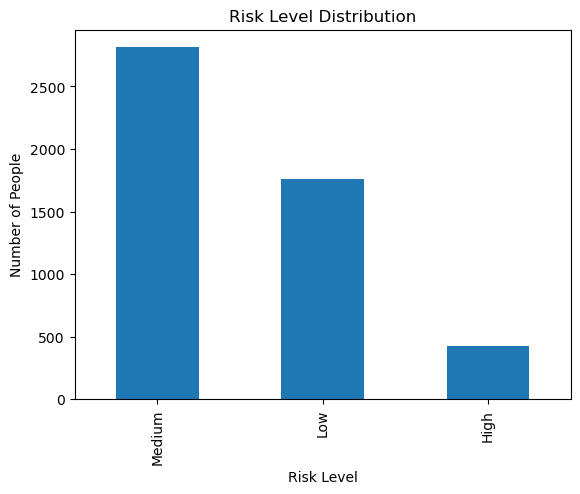

In [186]:


df['risk_level'].value_counts().plot(kind='bar')

plt.title('Risk Level Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Number of People')
plt.show()

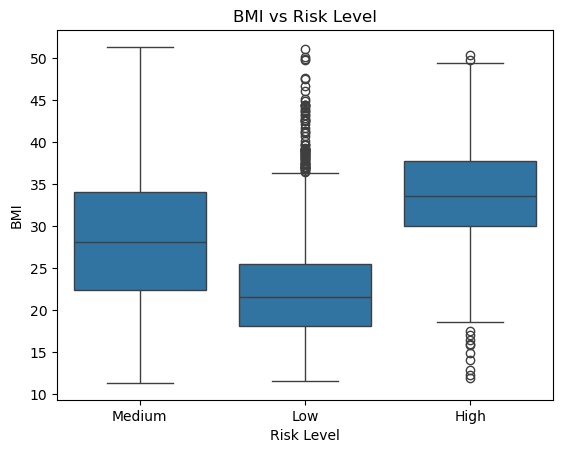

In [187]:


sns.boxplot(x='risk_level', y='BMI', data=df)

plt.title('BMI vs Risk Level')
plt.xlabel('Risk Level')
plt.ylabel('BMI')
plt.show()

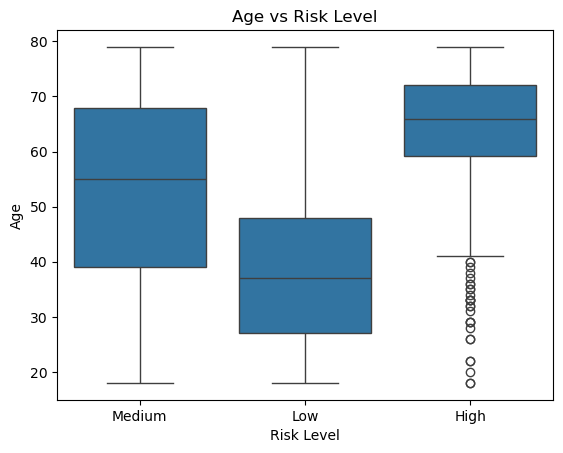

In [188]:
sns.boxplot(x='risk_level', y='age', data=df)

plt.title('Age vs Risk Level')
plt.xlabel('Risk Level')
plt.ylabel('Age')
plt.show()

In [189]:
pd.crosstab(df['exercise'], df['risk_level'])

risk_level,High,Low,Medium
exercise,,,
high,20,480,500
low,127,284,861
medium,69,933,983
none,210,64,469


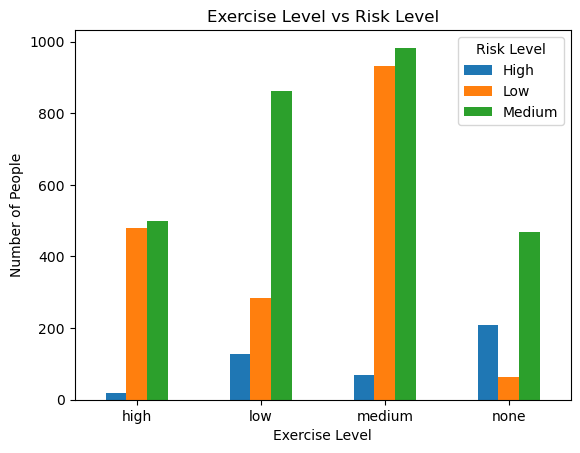

In [190]:
pd.crosstab(df['exercise'], df['risk_level']).plot(kind='bar')

plt.title('Exercise Level vs Risk Level')
plt.xlabel('Exercise Level')
plt.ylabel('Number of People')
plt.xticks(rotation=0)
plt.legend(title='Risk Level')
plt.show()

In [191]:
pd.crosstab(df['smoking'], df['risk_level'])

risk_level,High,Low,Medium
smoking,,,
no,246,1583,2194
yes,180,178,619


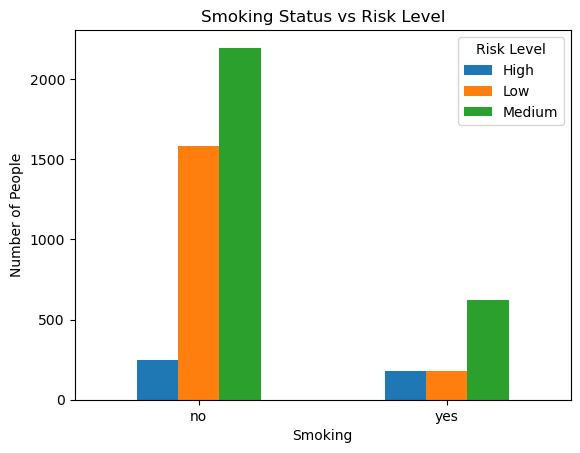

In [192]:
pd.crosstab(df['smoking'], df['risk_level']).plot(kind='bar')

plt.title('Smoking Status vs Risk Level')
plt.xlabel('Smoking')
plt.ylabel('Number of People')
plt.xticks(rotation=0)
plt.legend(title='Risk Level')
plt.show()

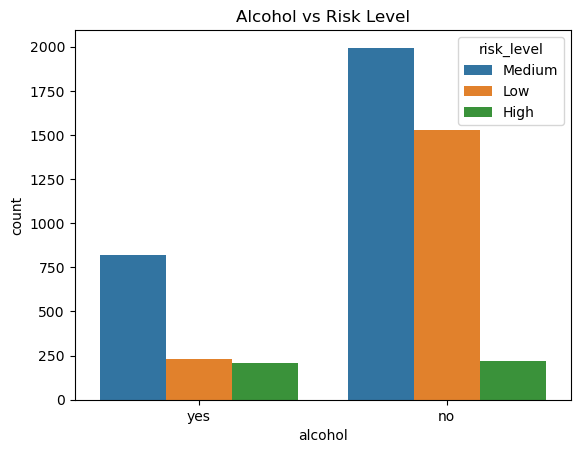

In [193]:
sns.countplot(x='alcohol', hue='risk_level', data=df)

plt.title('Alcohol vs Risk Level')
plt.show()

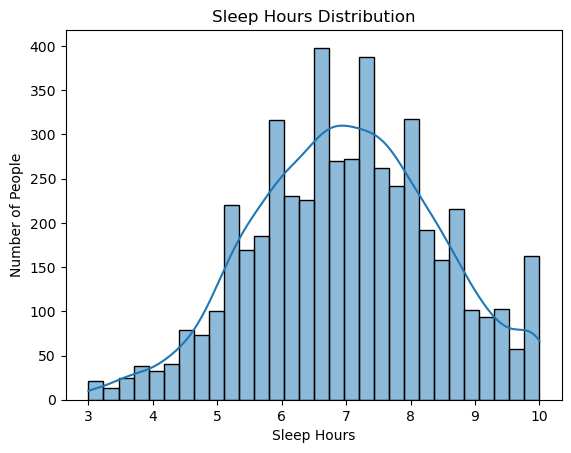

In [194]:
sns.histplot(df['sleep'], kde=True)

plt.title('Sleep Hours Distribution')
plt.xlabel('Sleep Hours')
plt.ylabel('Number of People')
plt.show()

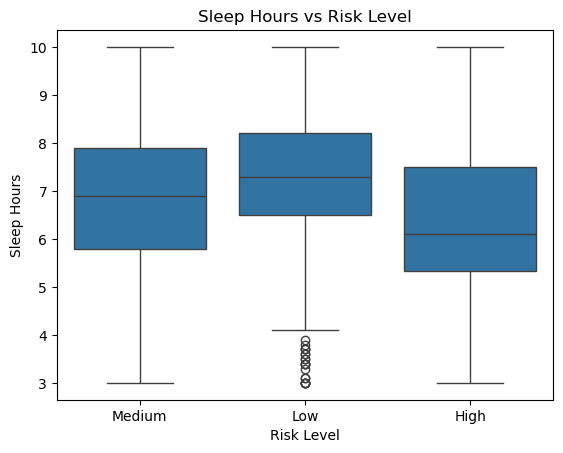

In [195]:
sns.boxplot(x='risk_level', y='sleep', data=df)

plt.title('Sleep Hours vs Risk Level')
plt.xlabel('Risk Level')
plt.ylabel('Sleep Hours')
plt.show()

# Data Preprocessing

In [196]:
df.isna().sum()

age             0
weight          0
height          0
exercise        0
sleep           0
sugar_intake    0
smoking         0
alcohol         0
married         0
profession      0
BMI             0
risk_score      0
risk_level      0
dtype: int64

In [197]:
df.duplicated().sum()

np.int64(0)

In [198]:
df.head()

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,BMI,risk_score,risk_level
0,56,67,195,low,6.1,medium,yes,yes,yes,office_worker,17.619987,4,Medium
1,69,76,170,high,6.9,high,no,no,no,teacher,26.297578,4,Medium
2,46,106,153,high,6.6,low,yes,no,no,artist,45.281729,4,Medium
3,32,54,186,medium,8.5,medium,no,no,no,artist,15.608741,0,Low
4,60,98,195,high,8.0,low,no,no,yes,teacher,25.772518,2,Low


# Encoding

In [203]:
df1 = df

In [204]:
df1.head()

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,BMI,risk_score,risk_level
0,56,67,195,low,6.1,medium,yes,yes,yes,office_worker,17.619987,4,Medium
1,69,76,170,high,6.9,high,no,no,no,teacher,26.297578,4,Medium
2,46,106,153,high,6.6,low,yes,no,no,artist,45.281729,4,Medium
3,32,54,186,medium,8.5,medium,no,no,no,artist,15.608741,0,Low
4,60,98,195,high,8.0,low,no,no,yes,teacher,25.772518,2,Low


In [205]:
df1 = pd.get_dummies(
    df1,
    columns=['exercise', 'sugar_intake', 'smoking', 'alcohol', 'married', 'profession'],
    drop_first=True
)

In [206]:
df1.head()

,age,weight,height,sleep,BMI,risk_score,risk_level,exercise_low,exercise_medium,exercise_none,...,smoking_yes,alcohol_yes,married_yes,profession_doctor,profession_driver,profession_engineer,profession_farmer,profession_office_worker,profession_student,profession_teacher
0,56,67,195,6.1,17.619987,4,Medium,True,False,False,...,True,True,True,False,False,False,False,True,False,False
1,69,76,170,6.9,26.297578,4,Medium,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,46,106,153,6.6,45.281729,4,Medium,False,False,False,...,True,False,False,False,False,False,False,False,False,False
3,32,54,186,8.5,15.608741,0,Low,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,60,98,195,8.0,25.772518,2,Low,False,False,False,...,False,False,True,False,False,False,False,False,False,True


In [207]:
df1.columns

Index(['age', 'weight', 'height', 'sleep', 'BMI', 'risk_score', 'risk_level',
       'exercise_low', 'exercise_medium', 'exercise_none', 'sugar_intake_low',
       'sugar_intake_medium', 'smoking_yes', 'alcohol_yes', 'married_yes',
       'profession_doctor', 'profession_driver', 'profession_engineer',
       'profession_farmer', 'profession_office_worker', 'profession_student',
       'profession_teacher'],
      dtype='object')

In [208]:
df1['risk_level'] = df1['risk_level'].map({
    'Low': 0,
    'Medium': 1,
    'High': 2
})

In [209]:
df1['risk_level'].value_counts()

risk_level
1    2813
0    1761
2     426
Name: count, dtype: int64

In [210]:
X = df1.drop(columns=['risk_score', 'risk_level'])

In [211]:
X.head()

,age,weight,height,sleep,BMI,exercise_low,exercise_medium,exercise_none,sugar_intake_low,sugar_intake_medium,smoking_yes,alcohol_yes,married_yes,profession_doctor,profession_driver,profession_engineer,profession_farmer,profession_office_worker,profession_student,profession_teacher
0,56,67,195,6.1,17.619987,True,False,False,False,True,True,True,True,False,False,False,False,True,False,False
1,69,76,170,6.9,26.297578,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2,46,106,153,6.6,45.281729,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False
3,32,54,186,8.5,15.608741,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False
4,60,98,195,8.0,25.772518,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True


In [212]:
X.shape

(5000, 20)

In [213]:
y = df1['risk_level']

In [214]:
from sklearn.model_selection import train_test_split

In [216]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [217]:
from sklearn.preprocessing import StandardScaler

In [218]:
scaler = StandardScaler()

In [219]:
X_train_scaled = scaler.fit_transform(X_train)

In [220]:
X_test_scaled = scaler.transform(X_test)


In [222]:
from sklearn.linear_model import LogisticRegression
model_LR = LogisticRegression(max_iter=1000)

model_LR.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [223]:
y_pred_LR = model_LR.predict(X_test_scaled)

In [225]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy_score(y_test, y_pred_LR)

0.876

In [226]:
confusion_matrix(y_test, y_pred_LR)

array([[310,  42,   0],
       [ 39, 508,  16],
       [  0,  27,  58]])

In [227]:
print(classification_report(y_test, y_pred_LR))

              precision    recall  f1-score   support

           0       0.89      0.88      0.88       352
           1       0.88      0.90      0.89       563
           2       0.78      0.68      0.73        85

    accuracy                           0.88      1000
   macro avg       0.85      0.82      0.84      1000
weighted avg       0.87      0.88      0.88      1000



In [231]:
from sklearn.tree import DecisionTreeClassifier

model_DT = DecisionTreeClassifier(random_state=42)

In [232]:
model_DT.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [233]:
y_pred_DT = model_DT.predict(X_test)

In [234]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy_score(y_test, y_pred_DT)

0.927

In [235]:
confusion_matrix(y_test, y_pred_DT)

array([[333,  19,   0],
       [ 17, 528,  18],
       [  0,  19,  66]])